# Healthcare Readmission Prediction
## 02 — Exploratory Data Analysis (EDA) and Visualization

This notebook generates the actual Week 3 numerical summaries and visualizations from the public UCI Diabetes 130-US Hospitals dataset.

## Objectives
1. Examine the readmission outcome distribution.
2. Explore age-group patterns.
3. Compare length of stay and laboratory procedures across readmission groups.
4. Summarize healthcare utilization.
5. Create a complete Spearman correlation matrix and heatmap.
6. Investigate potential numerical outliers.

**Interpretation rule:** association does not establish causation.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#from ucimlrepo import fetch_ucirepo
%pip install ucimlrepo

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [25]:
from ucimlrepo import fetch_ucirepo
%pip install ucimlrepo

## 1. Load and prepare the dataset

In [26]:
diabetes = fetch_ucirepo(id=296)
X = diabetes.data.features.copy()
y = diabetes.data.targets.copy()
df = pd.concat([X, y], axis=1)
df = df.replace('?', np.nan)
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print('Rows:', len(df))
print('Columns:', len(df.columns))
print('30-day readmission cases:', int(df['readmitted_30d'].sum()))

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Rows: 101766
Columns: 49
30-day readmission cases: 11357


## 2. Data overview and descriptive statistics

In [27]:
print('Dataset shape:', df.shape)
print('\nReadmission distribution:')
display(df['readmitted'].value_counts(dropna=False))
print('\nNumerical descriptive statistics:')
display(df.select_dtypes(include=np.number).describe().T.round(2))

Dataset shape: (101766, 49)

Readmission distribution:


,count
readmitted,
NO,54864
>30,35545
<30,11357



Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.02,1.45,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.72,5.28,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.75,4.06,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0


## 3. Readmission distribution

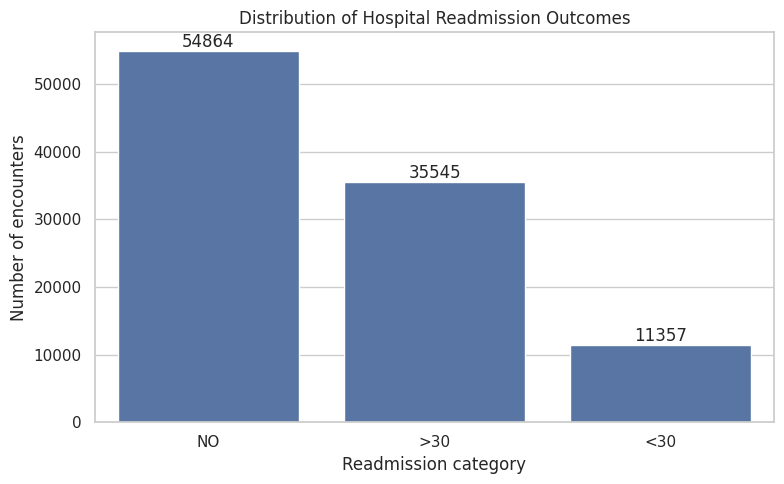

,encounters
readmitted,
NO,54864
>30,35545
<30,11357


In [28]:
readmission_counts = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])

plt.figure(figsize=(8,5))
ax = sns.barplot(x=readmission_counts.index, y=readmission_counts.values)
plt.title('Distribution of Hospital Readmission Outcomes')
plt.xlabel('Readmission category')
plt.ylabel('Number of encounters')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()
display(readmission_counts.to_frame('encounters'))

## 4. Age-group distribution

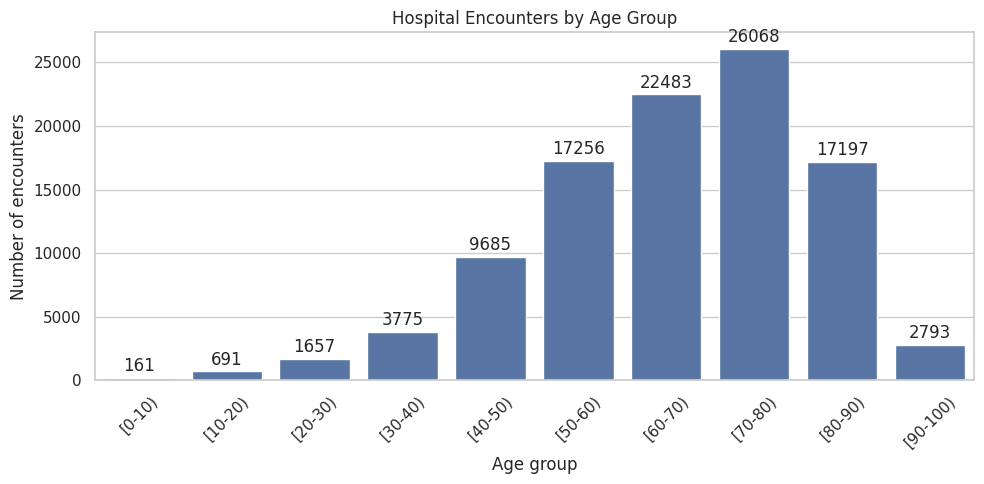

,encounters
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


In [29]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_counts = df['age'].value_counts().reindex(age_order).fillna(0)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title('Hospital Encounters by Age Group')
plt.xlabel('Age group')
plt.ylabel('Number of encounters')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)
plt.tight_layout()
plt.show()
display(age_counts.to_frame('encounters'))

## 5. 30-day readmission rate by age group

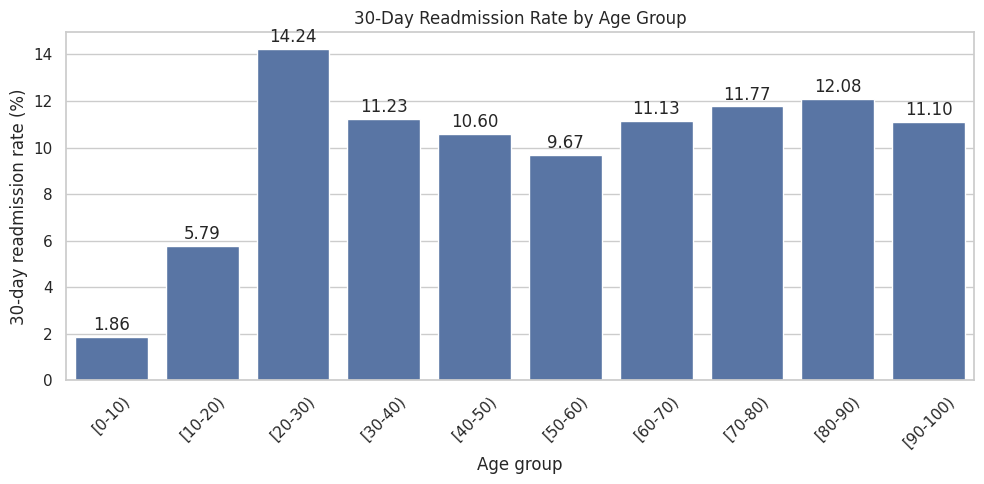

,count,sum,readmission_rate_percent
age,,,
[0-10),161,3,1.86
[10-20),691,40,5.79
[20-30),1657,236,14.24
[30-40),3775,424,11.23
[40-50),9685,1027,10.60
[50-60),17256,1668,9.67
[60-70),22483,2502,11.13
[70-80),26068,3069,11.77
[80-90),17197,2078,12.08


In [30]:
age_readmission = (df.groupby('age', observed=False)['readmitted_30d'].agg(['count','sum','mean']).reindex(age_order))
age_readmission['readmission_rate_percent'] = (age_readmission['mean'] * 100).round(2)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=age_readmission.index, y=age_readmission['readmission_rate_percent'])
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age group')
plt.ylabel('30-day readmission rate (%)')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()
display(age_readmission[['count','sum','readmission_rate_percent']])

## 6. Length of hospital stay by readmission outcome

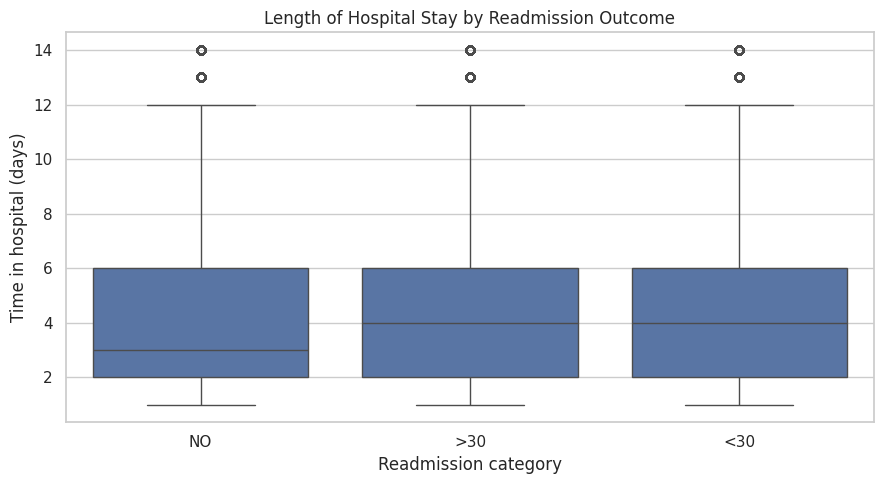

,count,mean,median,std,min,max
readmitted,,,,,,
NO,54864,4.25,3.0,2.96,1,14
>30,35545,4.50,4.0,2.99,1,14
<30,11357,4.77,4.0,3.03,1,14


In [31]:
plot_df = df[df['readmitted'].isin(['NO','>30','<30'])].copy()

plt.figure(figsize=(9,5))
sns.boxplot(data=plot_df, x='readmitted', y='time_in_hospital', order=['NO','>30','<30'])
plt.title('Length of Hospital Stay by Readmission Outcome')
plt.xlabel('Readmission category')
plt.ylabel('Time in hospital (days)')
plt.tight_layout()
plt.show()

stay_summary = (plot_df.groupby('readmitted')['time_in_hospital'].agg(['count','mean','median','std','min','max']).reindex(['NO','>30','<30']).round(2))
display(stay_summary)

## 7. Laboratory procedures by readmission outcome

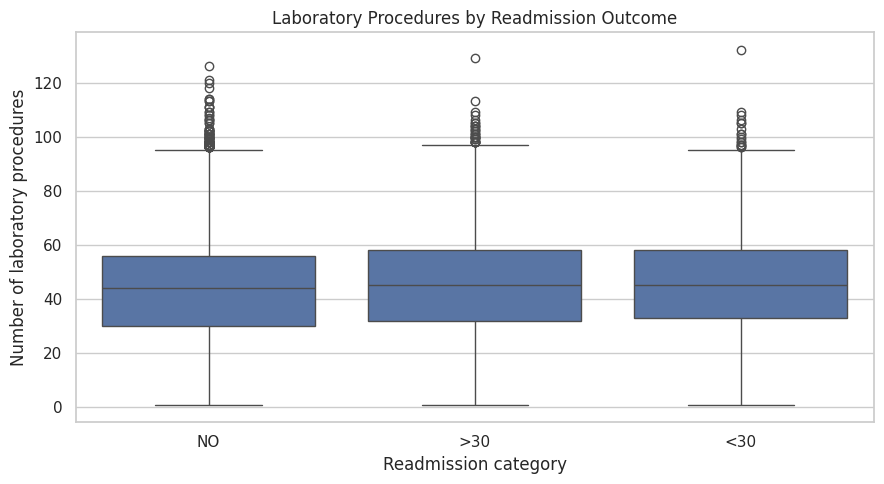

,count,mean,median,std,min,max
readmitted,,,,,,
NO,54864,42.38,44.0,19.80,1,126
>30,35545,43.84,45.0,19.57,1,129
<30,11357,44.23,45.0,19.28,1,132


In [32]:
plt.figure(figsize=(9,5))
sns.boxplot(data=plot_df, x='readmitted', y='num_lab_procedures', order=['NO','>30','<30'])
plt.title('Laboratory Procedures by Readmission Outcome')
plt.xlabel('Readmission category')
plt.ylabel('Number of laboratory procedures')
plt.tight_layout()
plt.show()

lab_summary = (plot_df.groupby('readmitted')['num_lab_procedures'].agg(['count','mean','median','std','min','max']).reindex(['NO','>30','<30']).round(2))
display(lab_summary)

## 8. Healthcare-utilization summary

In [33]:
utilization_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']
utilization_summary = df[utilization_cols].describe().T.round(2)
display(utilization_summary)

df['total_prior_utilization'] = (df['number_outpatient'].fillna(0) + df['number_emergency'].fillna(0) + df['number_inpatient'].fillna(0))
print('Total prior utilization summary:')
display(df['total_prior_utilization'].describe().round(2).to_frame('total_prior_utilization'))

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


Total prior utilization summary:


,total_prior_utilization
count,101766.00
mean,1.20
std,2.29
min,0.00
25%,0.00
50%,0.00
75%,2.00
max,80.00


## 9. Complete Spearman correlation matrix

Identifier fields such as `encounter_id` and `patient_nbr` are excluded because they are identifiers rather than clinical measurements. Spearman correlation is used for exploratory monotonic associations.

In [34]:
correlation_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses','total_prior_utilization','readmitted_30d']
correlation_matrix = df[correlation_cols].corr(method='spearman').round(3)
print('Complete Spearman correlation matrix:')
display(correlation_matrix)

Complete Spearman correlation matrix:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_prior_utilization,readmitted_30d
time_in_hospital,1.000,0.337,0.187,0.465,-0.013,-0.001,0.092,0.237,0.055,0.051
num_lab_procedures,0.337,1.000,0.023,0.252,-0.024,0.006,0.041,0.169,0.016,0.021
num_procedures,0.187,0.023,1.000,0.352,-0.024,-0.046,-0.064,0.067,-0.071,-0.006
num_medications,0.465,0.252,0.352,1.000,0.074,0.044,0.099,0.294,0.108,0.045
number_outpatient,-0.013,-0.024,-0.024,0.074,1.000,0.177,0.156,0.113,0.578,0.034
number_emergency,-0.001,0.006,-0.046,0.044,0.177,1.000,0.222,0.092,0.464,0.063
number_inpatient,0.092,0.041,-0.064,0.099,0.156,0.222,1.000,0.136,0.796,0.138
number_diagnoses,0.237,0.169,0.067,0.294,0.113,0.092,0.136,1.000,0.170,0.047
total_prior_utilization,0.055,0.016,-0.071,0.108,0.578,0.464,0.796,0.170,1.000,0.124
readmitted_30d,0.051,0.021,-0.006,0.045,0.034,0.063,0.138,0.047,0.124,1.000


## 10. Correlation heatmap

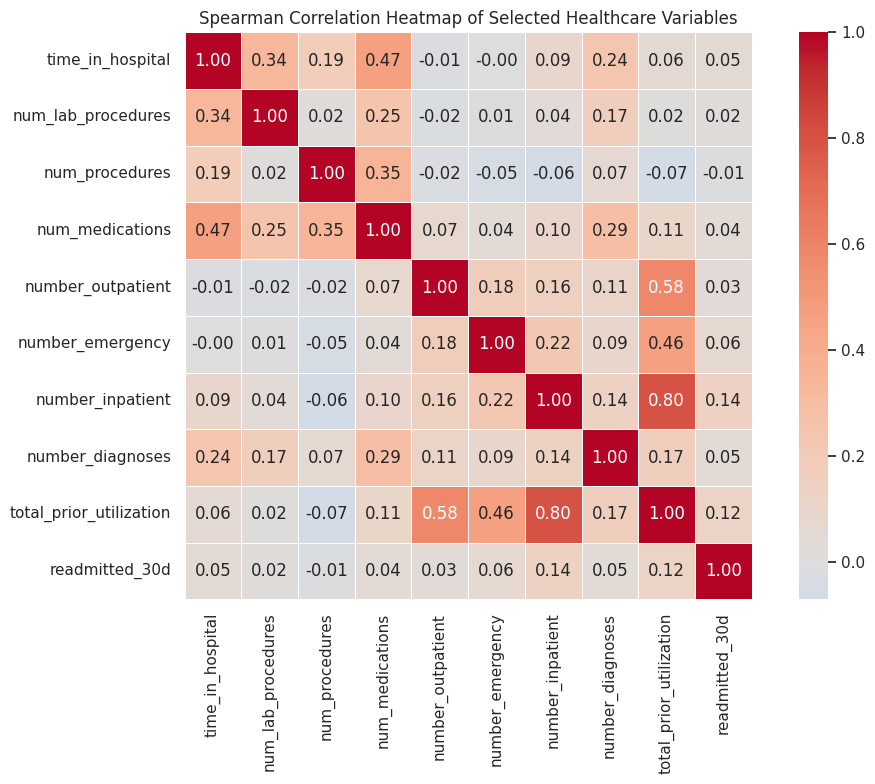

In [35]:
plt.figure(figsize=(11,8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Spearman Correlation Heatmap of Selected Healthcare Variables')
plt.tight_layout()
plt.show()

## 11. Strongest exploratory associations with 30-day readmission

In [36]:
target_correlations = correlation_matrix['readmitted_30d'].drop('readmitted_30d').sort_values(key=lambda s: s.abs(), ascending=False)
display(target_correlations.to_frame('spearman_correlation_with_readmitted_30d'))

,spearman_correlation_with_readmitted_30d
number_inpatient,0.138
total_prior_utilization,0.124
number_emergency,0.063
time_in_hospital,0.051
number_diagnoses,0.047
num_medications,0.045
number_outpatient,0.034
num_lab_procedures,0.021
num_procedures,-0.006


## 12. Numerical outlier investigation using the IQR rule

In [37]:
outlier_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']
rows = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    rows.append({'variable':col,'Q1':q1,'Q3':q3,'IQR':iqr,'lower_bound':lower,'upper_bound':upper,'outlier_count':count,'outlier_percent':count/len(df)*100})
outlier_summary = pd.DataFrame(rows).round(2)
display(outlier_summary)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,time_in_hospital,2.0,6.0,4.0,-4.0,12.0,2252,2.21
1,num_lab_procedures,31.0,57.0,26.0,-8.0,96.0,143,0.14
2,num_procedures,0.0,2.0,2.0,-3.0,5.0,4954,4.87
3,num_medications,10.0,20.0,10.0,-5.0,35.0,2557,2.51
4,number_outpatient,0.0,0.0,0.0,0.0,0.0,16739,16.45
5,number_emergency,0.0,0.0,0.0,0.0,0.0,11383,11.19
6,number_inpatient,0.0,1.0,1.0,-1.5,2.5,7049,6.93
7,number_diagnoses,6.0,9.0,3.0,1.5,13.5,281,0.28


## 13. EDA evidence summary

Use the generated tables and charts to write the Week 3 report. Report exact values from the outputs rather than illustrative numbers.

When interpreting differences, consider sample size and distribution. Correlations describe association, not causation. A flagged outlier is not automatically an erroneous healthcare record.

In [38]:
evidence = pd.DataFrame({
    'metric': ['Total encounters','Early readmissions (<30)','30-day readmission rate (%)'],
    'value': [len(df), int(df['readmitted_30d'].sum()), round(df['readmitted_30d'].mean()*100,2)]
})
display(evidence)

,metric,value
0,Total encounters,101766.00
1,Early readmissions (<30),11357.00
2,30-day readmission rate (%),11.16


## 14. Week 3 conclusion

The EDA stage provides numerical and visual evidence for the later modelling stage. The readmission distribution establishes the target imbalance; age and outcome comparisons identify patterns for further investigation; boxplots show distribution and potential outliers; utilization summaries quantify healthcare-use variables; and the complete Spearman matrix identifies exploratory associations among selected numerical variables.

These findings should guide feature selection and modelling without being presented as proof of clinical causation.